In [159]:
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
import shap
from feature_engine.selection import DropCorrelatedFeatures

In [160]:
# 타이타닉데이터로 보루타 알고리즘으로 피처를 선정하자!

df = sns.load_dataset('titanic')

#데이터 전처리

df = df.dropna(subset=['age','embarked','deck'])
df['sex'] =df['sex'].map({'male':0,'female':1})
df['embarked'] =df['embarked'].astype('category').cat.codes
df['deck'] = df['deck'].astype('category').cat.codes

#필요한 피처만 추출

X = df[['pclass','sex','age','sibsp','parch','fare','embarked','deck']]
y = df['survived']

In [161]:
## 보루타를 통한 피처셀렉션을 위해 RandomForestClassifier

rf= RandomForestClassifier(class_weight = 'balanced', max_depth=5)

# BorutaPy 불러오기
boruta_selector = BorutaPy(rf, n_estimators = 'auto', random_state=111)
boruta_selector.fit(X.values, y.values) #행렬로 대입해서

BorutaPy(estimator=RandomForestClassifier(class_weight='balanced', max_depth=5,
                                          n_estimators=80,
                                          random_state=RandomState(MT19937) at 0x2389D5BF740),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x2389D5BF740)

In [162]:
print('선택된 특성',X.columns[boruta_selector.support_].tolist())

선택된 특성 ['sex', 'age', 'fare']


- 모든 특성의 중요도를 평가하고, 쉐도우 변수를 만들어서 중요도가 무작위로 중요도를 비교하고 이 무작위보다 높은 중요도가 높은 특성들을 추출한것

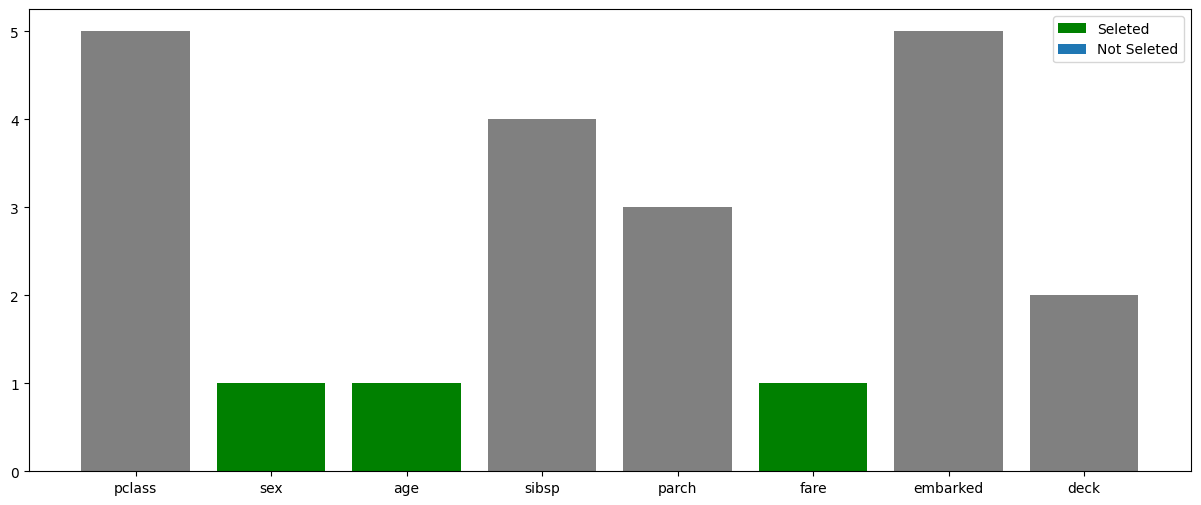

In [163]:
import matplotlib.pyplot as plt

green_area = X.columns[boruta_selector.support_].tolist()
blue_area = X.columns[boruta_selector.support_weak_].tolist()

# 중요도 랭킹으로 확인하기
feature_importance = boruta_selector.ranking_

# 시각화로 살펴보기

plt.figure(figsize=(15,6))
plt.bar(X.columns, feature_importance,color= 'grey')
plt.bar(green_area, [1]*len(green_area), color='green', label='Seleted')
plt.bar(blue_area, [2]*len(blue_area), color='blue', label='Not Seleted')
plt.legend()

### Shap value(샤플리 값)
- 샤플리 값의 작동방식을 이해하자!
- 간단한 예시를 통해 어떤 방식으로 계산하는지 이해하기!
    - 세명의 플레이어(피처) A,B,C 가 협력해서 매출 100 달성(MLy값을 예측한다.
    - A와 B가 같이 협력을 하면 매출 60을 달성
    - B와 C가 같이 협력을 하면 매출 50을 달성
    - A,b,c가 모두 협력하면 매출 100을 달성
    - 기여도는 어떻게 계산이 되는가?
        - 각 조합의 기여도를 계산
        - 공집합 = 기여도가 0, A,B,C 모두 진행하지 않는 것을 의미
        - A만 한 경우 20, B만 한 경우 30, C만 한 경우 10
        - A,B = 60, B,C = 50, A,C = 40
        - A,B,C = 100
    - 샤플리 A값을 계산한다고 하면 샤플리 값 = 1/6(20)+1/6(10)+1/6(40-10)+1/6(60-30) + 1/6(100-60)
 
- ML에서 샤플리 값을 계산한다면
    - Feature 모델의 예측값에 기여한 정도를 계산하기 위해 샤플리 값을 사용한다.
    - 피처들의 조합으로 게임 플레이어처럼 생각하고, 모델의 예측값을 협력의 결과로 본다
    - 데이터 포인트에 대해 모델의 예측값을 계산
    - 모든 특성의 조합에서의 예측값이 변화를 계산
    - 각 특성의 기여도를 평균화하여서 샤플리 값을 계산
 
### 샤플리 값을 타이타닉 데이터로 설명을 해보면!
- 타이타닉의 주요 특성(피처) pclass, sex, age, fare타겟변수는 survived
- 랜덤포레스트를 학습해서 특정 포인트에서 새플리 값을 계산해본다.

-----
- 특성 N은
    - Pclass(객실등급), Sex(성별), age(나이), Fare(요금)
- 모든 특성의 조합을 생각해야한다.
    - 공집합
    - Pclass
    - sex
    - age
    - Fare
    - (plass, sex)
    - ...
    - (pclass, sex, age, fare)
    - 모든 조합을 생성한다.
- 모델의 예측값을 계산한다.
    - 수식에서 바라보면
    - S = pclass i = sex, pclass와 sex를 함께 사용하여 예측값을 계산
    - f(SU{i} - f{S}) 특성인 sex 추가가 되었을때 예측값에 미친 변화량을 계산
- 평균화
    - 모든 부분집합 (S)에 대한 기여도를 계산하는 것, 이를 평균화하여 특성 (i)샤플리 값을 얻는 것
- 특정 데이터 포인트에 대해 샤플리 값을 다 계산이 된다.
- 변수 샤플리 값 해석
- pclass -0.3낮은 객실등급들이 생존 확률을 감소시킨다.
- sex +0.5 여성의 경우 생존확률 증가시킨다.
- age -0.2 나이가 많아 질수록 생존에 대한 확률이 감소
- fare +0.1 운임이 높으면 생존확률을 증가시킨다.
-  타이타닉 도메인을 이해하고 샤플리 값을 바라보면 피처에 대한 선택과 인사이트를 상대적으로 쉽게 정리할 수 있다. 

In [164]:
from sklearn.model_selection import train_test_split

X= df[['sex','age','fare','pclass']]
y= df['survived']

In [165]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 111)

In [166]:
model = RandomForestClassifier(random_state=111)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=111)

In [167]:
# Shap 값 구하기
# SHAP Explainer
explainer = shap.TreeExplainer(model, X_train)

In [168]:
# shap_values 추출
shap_values = explainer.shap_values(X_test)

In [169]:
shap_values

array([[[ 2.30433329e-01, -2.30433327e-01],
        [ 1.46649997e-01, -1.46649997e-01],
        [-2.12566663e-01,  2.12566662e-01],
        [ 1.88333342e-03, -1.88333328e-03]],

       [[-1.35199999e-01,  1.35199995e-01],
        [-6.91833315e-02,  6.91833318e-02],
        [-4.82499989e-02,  4.82499990e-02],
        [-2.09666668e-02,  2.09666662e-02]],

       [[ 3.25783327e-01, -3.25783323e-01],
        [ 5.45666661e-02, -5.45666655e-02],
        [ 2.08516662e-01, -2.08516663e-01],
        [ 7.53333345e-03, -7.53333303e-03]],

       [[-1.80083331e-01,  1.80083328e-01],
        [-4.92333330e-02,  4.92333318e-02],
        [-5.23666655e-02,  5.23666660e-02],
        [-1.91666657e-03,  1.91666668e-03]],

       [[ 2.02524997e-01, -2.02524994e-01],
        [-1.29749995e-02,  1.29750002e-02],
        [-1.01574998e-01,  1.01574998e-01],
        [-1.57499987e-03,  1.57500008e-03]],

       [[-1.57166665e-01,  1.57166662e-01],
        [-6.41833319e-02,  6.41833326e-02],
        [-5.91666652e-

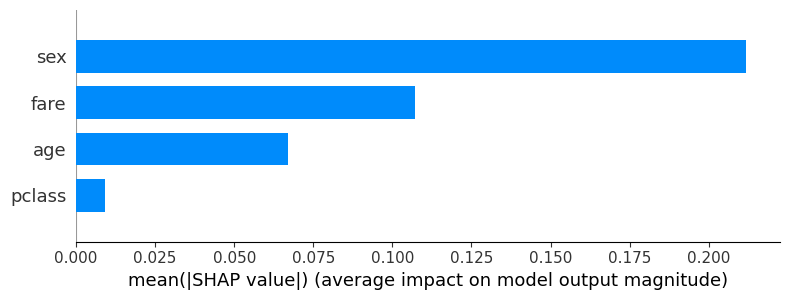

In [170]:
shap.summary_plot(shap_values[:, :, 0], X_test, plot_type='bar', feature_names=X_test.columns.tolist())

### Shap의 그래프를 더 살펴보고 해당 그래프를 해석해보자
- summary_plot : 특정 중요도, 기여도 확인
- bar_plot : 중요도 순서 확인
- force_plot : 개별 예측 해석
- decision_plot : 예측 경로에 대한 분석
- dependence_plot : 특성과 출력간의 관계분석
- interation_plot : 상호작용 분석
- waterfall_plot : 예측 생성과정 단계별 설명
- heatmap_plot : 상호작용간의 분석
- beesaem_plot : 분산, 중심성향 분석

In [171]:
## Shap값을 통해 중요도를 계산하고 확인해 보자!
shap_df=pd.DataFrame(shap_values[:, :, 0], columns = X_test.columns)

In [172]:
## shap_df 중요도를 계산 후 정렬해서 보기

shap_mean_importance =shap_df.abs().mean(axis=0).sort_values(ascending=False)

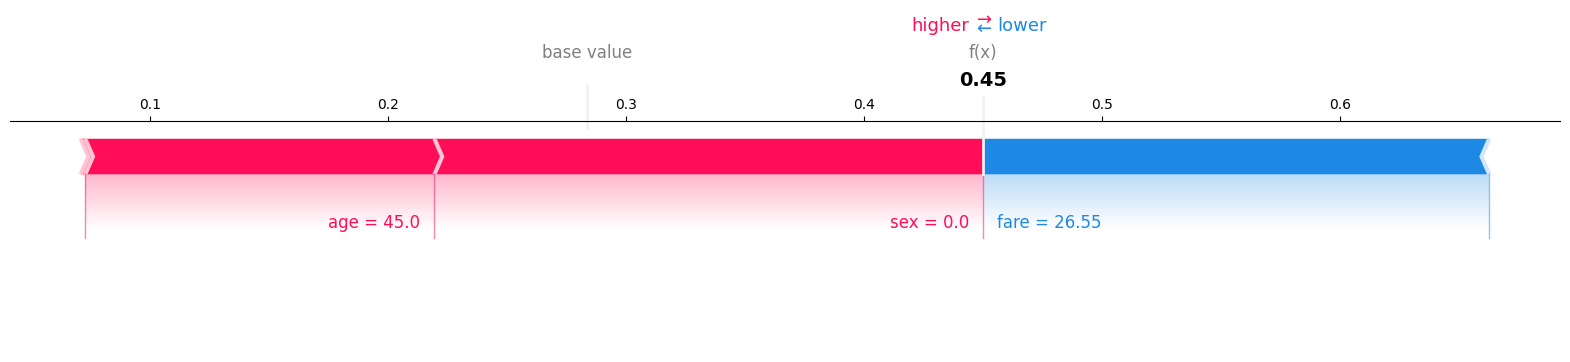

In [173]:
shap.force_plot(
    explainer.expected_value[0],  # 클래스 0의 expected value
    shap_values[0][:, 0],         # 클래스 0의 SHAP 값
    X_test.iloc[0, :],           # 첫 번째 샘플의 feature 값
    matplotlib=True
)

- 결과해석 : base_value 모델의 평군적인 예측을 말하는 것 0.3
- 특성에 대한 기여도를 확인해야한다.
    - 색상
    - 빨간색은 특성이 모델 예측값을 증가시키는 방향으로 기여
    - 파란색은 해당 특성이 모델 예측값을 감소시키는 방향으로 기여했다.
- f(x) : 0.45
    - 최종 모델 예측값으로, 모든 특성의 기여도를 합산한 값으로 최종 예측값이 0.44
- age, sex, fare 각 데이터 포인트 실제 값
- base_value 0.3에서 시작, 특성의 기여도를 더하거나 빼서 최종 예측값으로 0.44로 도달한다.
- age 0.1 증가시킨다. 나이가 45일대 생존 가능성을 증가하는 방향으로 작용
- sex 0 남성 0.2영향을 더 줬다.
- fare - 0.206 영향을 감소시켰다.

In [174]:
shap_values[0][:,0]

array([ 0.23043333,  0.14665   , -0.21256666,  0.00188333])

In [175]:
X_test.iloc[0,:]

sex        0.00
age       45.00
fare      26.55
pclass     1.00
Name: 536, dtype: float64

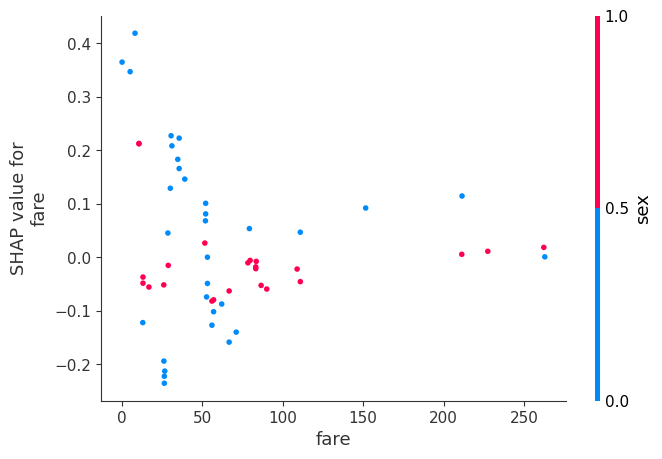

In [176]:
# 클래스 0에 대한 모든 샘플의 SHAP 값
shap_values_class0 = shap_values[:, :, 0]

# 'fare' 피처에 대한 SHAP dependence plot 생성
shap.dependence_plot('fare', shap_values_class0, X_test)


- fare의 shap값과 fare, sex의 상호작용 이해
- shap, fare, sex 특성들에 대해 이해를 할 수 있는데, 데이터가 어떤 트랜드를 반영하는지에 따라 위에 공유했던 자료처럼 해석하면 된다

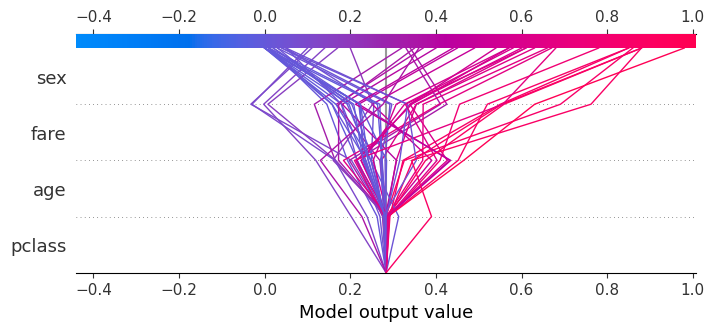

In [177]:
shap_values_class0 = shap_values[:, :, 0]

shap.decision_plot(
    explainer.expected_value[0],  # 클래스 0의 기대값
    shap_values_class0,           # 클래스 0에 대한 모든 샘플의 SHAP 값
    X_test                        # 원본 특징 데이터
)


- 특정 데이터의 포인트에서 모델의 예측경로를 시각적으로 표현하는 것
- 예측값에 기여한 누적 영향을 보여주는 것
- X축 (모델이 예측한 결과값의 스케일)
    - 예측값이 +특정 클래스 생존 가능성이 증가
    - 갈수록 생존에 대해서 불가능하게 만드는 것
- Y축
    - 피처
    - 모델이 예측을 내릴때 사용한 주요 특성들이 나열
- 선의 기울기
    - 완만한 기울기 : 예측값에 크게 기여하지 않았다.
    - 급격한 기울기 : 예측값에 크게 영향을 주었다.
- 선의 색상
    - 파란색 : 특성 값이 낮은 것
    - 빨간색 : 특성 값이 높은 것

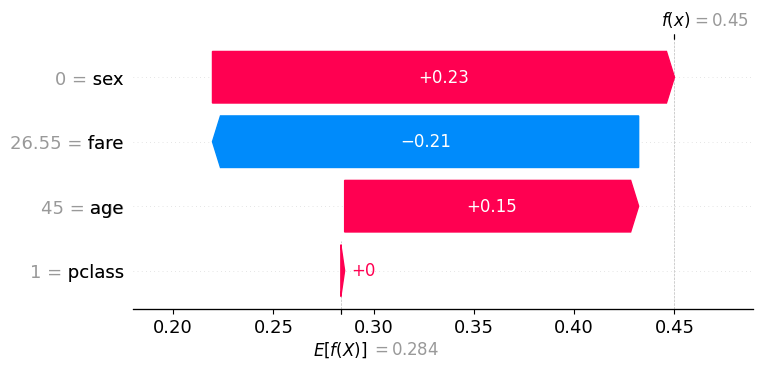

In [178]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0][:, 0],  # 클래스 0의 SHAP 값
        base_values=explainer.expected_value[0],  # 클래스 0의 base value
        data=X_test.iloc[0]  # 첫 번째 샘플의 피처 값
    )
)

In [179]:
## shap값을 통해 출력된 피처와 base 모델로 학습한 것을 비교하여 정말 피처 셀렉션이 긍정적인 영향을 주는가?


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

In [180]:
tt = sns.load_dataset('titanic')

In [181]:
tt = tt.drop(columns = ['deck', 'embark_town', 'class', 'alive', 'who', 'adult_male', 'alone'])

In [182]:
## 간단한 전처리
## 결측치는 다 제거하기
tt=tt.dropna()

In [183]:
tt

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
889,1,1,male,26.0,0,0,30.0000,C


In [184]:
tt['sex'] = tt['sex'].map({'male':0, 'female' : 1})
tt['embarked'] = tt['embarked'].map({'C' : 0, 'Q' : 1, 'S' :2})

In [185]:
## X, y로 데이터 나누기
X = tt.drop(columns = ['survived'])
y = tt['survived']

In [186]:
import numpy as np

In [187]:
## 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state =111)

## baseline modeling
rf_base = RandomForestClassifier(random_state = 111, max_depth = 5)
base_cv_scores = cross_val_score(rf_base, X_train, y_train, cv = 5, scoring = 'accuracy')
print(np.mean(base_cv_scores), '교차검증 Train')
## test 값으로 실제 성능 확인
rf_base.fit(X_train, y_train)
base_pred = rf_base.predict(X_test)
base_acc_test = accuracy_score(y_test, base_pred)
print(base_acc_test, 'test 결과')

# shap 피처 셀렉한 것으로 모델링
explainer = shap.TreeExplainer(rf_base)
shap_values = explainer.shap_values(X_train)

0.8031717171717171 교차검증 Train
0.8551401869158879 test 결과


In [188]:
## shap 중요도 계산
## 피처에 적용하기

shap_importance = np.abs(shap_values[1]).mean(axis = 0)
importance_features = X_train.columns[np.argsort(shap_importance)][::-1][:2]

## train 데이터에서 특성으로 추출
X_train_selected = X_train[importance_features]
X_test_selected = X_test[importance_features]

In [189]:
rf_selected = RandomForestClassifier(random_state=111, max_depth = 2)
selected_cv_scores = cross_val_score(rf_selected, X_train_selected, y_train, cv=5, scoring='accuracy')
print(np.mean(selected_cv_scores), '교차검증train')

## test 검증
rf_selected.fit(X_train_selected, y_train)
selected_y_pred = rf_selected.predict(X_test_selected)

## 정확도 검증
selected_acc_test = accuracy_score(y_test, selected_y_pred)
print(selected_acc_test, 'test 결과')

0.771090909090909 교차검증train
0.822429906542056 test 결과


In [190]:
## 피처의 중요도를 선택했을 때, 오히려 더 안좋은 성능을 보였다.
## 데이터 수가 너무 적은 것도 있고, 전처리 안하고 날려서 성능을 비교하는 게 좀 적고
## 전처리나 다른 피처에 대한 엔지니어링 작업도 없었고
## 이미 데이터 자체를 피처가 빠지면 성능이 떨어질 수 밖에 없는 설명력의 상황일 수 있다.
## Train 훨씬 낮고, test가 높은 과소적합의 상태이기 때문에 이 부분을 이야기 하는게 모순이다.